# Reuters-21578

## 1. Reuters-21578 Dataset Loading


In [1]:
import os
import pandas as pd
from bs4 import BeautifulSoup
from collections import Counter
import re

# Set path to reuters data directory
reuters_dir = "../data/reuters"

def parse_reuters_sgm(file_path):
    """Parse a Reuters SGML file and extract documents."""
    with open(file_path, 'r', encoding='latin-1', errors='ignore') as f:
        content = f.read()
    
    # Fix malformed SGML
    content = content.replace('<!DOCTYPE lewis SYSTEM "lewis.dtd">', '')
    content = '<ROOT>' + content + '</ROOT>'
    
    soup = BeautifulSoup(content, 'html.parser')
    documents = []
    
    for doc in soup.find_all('reuters'):
        doc_dict = {}
        
        # Get attributes
        doc_dict['newid'] = doc.get('newid', '')
        doc_dict['lewissplit'] = doc.get('lewissplit', '')
        doc_dict['cgisplit'] = doc.get('cgisplit', '')
        doc_dict['oldid'] = doc.get('oldid', '')
        doc_dict['topics_attribute'] = doc.get('topics', '')
        
        # Extract topics
        topics_tag = doc.find('topics')
        if topics_tag:
            doc_dict['topics'] = [d.text for d in topics_tag.find_all('d')]
        else:
            doc_dict['topics'] = []
        
        # Extract places
        places_tag = doc.find('places')
        if places_tag:
            doc_dict['places'] = [d.text for d in places_tag.find_all('d')]
        else:
            doc_dict['places'] = []
        
        # Extract people
        people_tag = doc.find('people')
        if people_tag:
            doc_dict['people'] = [d.text for d in people_tag.find_all('d')]
        else:
            doc_dict['people'] = []
        
        # Extract orgs
        orgs_tag = doc.find('orgs')
        if orgs_tag:
            doc_dict['orgs'] = [d.text for d in orgs_tag.find_all('d')]
        else:
            doc_dict['orgs'] = []
        
        # Extract exchanges
        exchanges_tag = doc.find('exchanges')
        if exchanges_tag:
            doc_dict['exchanges'] = [d.text for d in exchanges_tag.find_all('d')]
        else:
            doc_dict['exchanges'] = []
        
        # Extract text content
        date_tag = doc.find('date')
        doc_dict['date'] = date_tag.text if date_tag else ''
        
        dateline_tag = doc.find('dateline')
        doc_dict['dateline'] = dateline_tag.text if dateline_tag else ''
        
        title_tag = doc.find('title')
        doc_dict['title'] = title_tag.text if title_tag else ''
        
        body_tag = doc.find('body')
        doc_dict['body'] = body_tag.text if body_tag else ''
        
        # Combine title and body for full text
        doc_dict['text'] = f"{doc_dict['title']} {doc_dict['body']}".strip()
        
        documents.append(doc_dict)
    
    return documents

# Load all Reuters SGML files
all_documents = []

sgm_files = sorted([f for f in os.listdir(reuters_dir) if f.startswith('reut2-') and f.endswith('.sgm')])
print(f"Found {len(sgm_files)} SGML files")

for filename in sgm_files:
    file_path = os.path.join(reuters_dir, filename)
    print(f"Processing {filename}...")
    docs = parse_reuters_sgm(file_path)
    all_documents.extend(docs)
    print(f"  Extracted {len(docs)} documents")

print(f"\nTotal documents extracted: {len(all_documents)}")

# Convert to DataFrame
df_reuters = pd.DataFrame(all_documents)
print(f"DataFrame shape: {df_reuters.shape}")
print(f"Columns: {list(df_reuters.columns)}")


Found 22 SGML files
Processing reut2-000.sgm...
  Extracted 1000 documents
Processing reut2-001.sgm...
  Extracted 1000 documents
Processing reut2-002.sgm...
  Extracted 1000 documents
Processing reut2-003.sgm...
  Extracted 1000 documents
Processing reut2-004.sgm...
  Extracted 1000 documents
Processing reut2-005.sgm...
  Extracted 1000 documents
Processing reut2-006.sgm...
  Extracted 1000 documents
Processing reut2-007.sgm...
  Extracted 1000 documents
Processing reut2-008.sgm...
  Extracted 1000 documents
Processing reut2-009.sgm...
  Extracted 1000 documents
Processing reut2-010.sgm...
  Extracted 1000 documents
Processing reut2-011.sgm...
  Extracted 1000 documents
Processing reut2-012.sgm...
  Extracted 1000 documents
Processing reut2-013.sgm...
  Extracted 1000 documents
Processing reut2-014.sgm...
  Extracted 1000 documents
Processing reut2-015.sgm...
  Extracted 1000 documents
Processing reut2-016.sgm...
  Extracted 1000 documents
Processing reut2-017.sgm...
  Extracted 1000 

In [2]:
# Display dataset overview
print(f"DataFrame shape: {df_reuters.shape}")
print(f"\nColumns: {list(df_reuters.columns)}")
print(f"\nFirst few rows:")
df_reuters.head()

DataFrame shape: (21578, 15)

Columns: ['newid', 'lewissplit', 'cgisplit', 'oldid', 'topics_attribute', 'topics', 'places', 'people', 'orgs', 'exchanges', 'date', 'dateline', 'title', 'body', 'text']

First few rows:


,newid,lewissplit,cgisplit,oldid,topics_attribute,topics,places,people,orgs,exchanges,date,dateline,title,body,text
0,1,TRAIN,TRAINING-SET,5544,YES,[cocoa],"[el-salvador, usa, uruguay]",[],[],[],26-FEB-1987 15:01:01.79,"SALVADOR, Feb 26 -",BAHIA COCOA REVIEW,Showers continued throughout the week in\nthe ...,BAHIA COCOA REVIEW Showers continued throughou...
1,2,TRAIN,TRAINING-SET,5545,NO,[],[usa],[],[],[],26-FEB-1987 15:02:20.00,"CLEVELAND, Feb 26 -",STANDARD OIL <SRD> TO FORM FINANCIAL UNIT,Standard Oil Co and BP North America\nInc said...,STANDARD OIL <SRD> TO FORM FINANCIAL UNIT Stan...
2,3,TRAIN,TRAINING-SET,5546,NO,[],[usa],[],[],[],26-FEB-1987 15:03:27.51,"HOUSTON, Feb 26 -",TEXAS COMMERCE BANCSHARES <TCB> FILES PLAN,Texas Commerce Bancshares Inc's Texas\nCommerc...,TEXAS COMMERCE BANCSHARES <TCB> FILES PLAN Tex...
3,4,TRAIN,TRAINING-SET,5547,NO,[],"[usa, brazil]",[],[],[],26-FEB-1987 15:07:13.72,"LOS ANGELES, Feb 26 -",TALKING POINT/BANKAMERICA <BAC> EQUITY OFFER,BankAmerica Corp is not under\npressure to act...,TALKING POINT/BANKAMERICA <BAC> EQUITY OFFER B...
4,5,TRAIN,TRAINING-SET,5548,YES,"[grain, wheat, corn, barley, oat, sorghum]",[usa],[],[],[],26-FEB-1987 15:10:44.60,"WASHINGTON, Feb 26 -",NATIONAL AVERAGE PRICES FOR FARMER-OWNED RESERVE,The U.S. Agriculture Department\nreported the ...,NATIONAL AVERAGE PRICES FOR FARMER-OWNED RESER...


### 1.1 Explorative Data analysis

In [3]:
# Count topic frequencies
from collections import Counter

all_topics = []
for topics_list in df_reuters['topics']:
    all_topics.extend(topics_list)

topic_counts = Counter(all_topics)
print(f"Total unique topics: {len(topic_counts)}")
print(f"\nTop 20 most common topics:")
for topic in topic_counts:
    print(f"  {topic}")

Total unique topics: 120

Top 20 most common topics:
  cocoa
  grain
  wheat
  corn
  barley
  oat
  sorghum
  veg-oil
  linseed
  lin-oil
  soy-oil
  sun-oil
  soybean
  oilseed
  sunseed
  earn
  acq
  copper
  housing
  money-supply
  coffee
  ship
  sugar
  trade
  reserves
  meal-feed
  soy-meal
  rye
  cotton
  carcass
  livestock
  crude
  nat-gas
  cpi
  gnp
  money-fx
  interest
  bop
  rice
  red-bean
  rubber
  copra-cake
  palm-oil
  palmkernel
  tea
  plywood
  alum
  gold
  platinum
  strategic-metal
  tapioca
  tin
  rapeseed
  groundnut-oil
  rape-oil
  cornglutenfeed
  citruspulp
  rape-meal
  wool
  dlr
  l-cattle
  retail
  ipi
  silver
  iron-steel
  hog
  propane
  heat
  gas
  jobs
  lei
  yen
  saudriyal
  zinc
  orange
  pet-chem
  fuel
  wpi
  potato
  lead
  groundnut
  can
  fishmeal
  income
  palladium
  nickel
  lumber
  jet
  instal-debt
  dfl
  dmk
  stg
  coconut-oil
  corn-oil
  inventories
  cpu
  peseta
  austdlr
  cotton-oil
  naphtha
  nzdlr
  rand

In [4]:
# Show all unique topics and singleton topics (count == 1)

all_unique_topics = sorted(topic_counts.keys())
singleton_topics = sorted([topic for topic, cnt in topic_counts.items() if cnt == 1])

print(f"Total unique topics: {len(all_unique_topics)}")
print("\nAll unique topic names (comma-separated):")
print(", ".join(all_unique_topics))

print("\n" + "=" * 80)
print(f"Topics that appear exactly once: {len(singleton_topics)}")
print("Singleton topics (comma-separated):")
print(", ".join(singleton_topics))

Total unique topics: 120

All unique topic names (comma-separated):
acq, alum, austdlr, barley, bfr, bop, can, carcass, castor-oil, castorseed, citruspulp, cocoa, coconut, coconut-oil, coffee, copper, copra-cake, corn, corn-oil, cornglutenfeed, cotton, cotton-oil, cottonseed, cpi, cpu, crude, cruzado, dfl, dkr, dlr, dmk, earn, f-cattle, fishmeal, fuel, gas, gnp, gold, grain, groundnut, groundnut-oil, heat, hk, hog, housing, income, instal-debt, interest, inventories, ipi, iron-steel, jet, jobs, l-cattle, lead, lei, lin-meal, lin-oil, linseed, lit, livestock, lumber, meal-feed, money-fx, money-supply, naphtha, nat-gas, nickel, nkr, nzdlr, oat, oilseed, orange, palladium, palm-oil, palmkernel, peseta, pet-chem, platinum, plywood, pork-belly, potato, propane, rand, rape-meal, rape-oil, rapeseed, red-bean, reserves, retail, rice, ringgit, rubber, rupiah, rye, saudriyal, sfr, ship, silver, skr, sorghum, soy-meal, soy-oil, soybean, stg, strategic-metal, sugar, sun-meal, sun-oil, sunseed, tap

## 2. Commodity timeseries

### 2.1 FED St. Louis

In [1]:
#!/usr/bin/env python3
import os
import time
import requests
import pandas as pd

# CONFIG
API_KEY    = "c91cd6fde4f6f5adc7be9d771ed16cd3"  # replace if needed
BASE_URL   = "https://api.stlouisfed.org/fred"
START_DATE = "1987-01-01"
END_DATE   = "1988-01-01"

OUTPUT_DIR = os.path.join("data", "Reuters commodities")
PER_DIR    = os.path.join(OUTPUT_DIR, "monthly_series")
os.makedirs(PER_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
FETCH_ERRORS_PATH = os.path.join(OUTPUT_DIR, "reuters_fred_fetch_errors.csv")

# Only prefer monthly candidates and fetch monthly observations
FREQ_PREFERENCE = ["m"]
FREQ_LABELS     = {"d": "Daily", "w": "Weekly", "m": "Monthly"}

# Reuters -> search terms (kept from your mapping)
REUTERS_TO_SEARCH = {
    "acq":            None,
    "alum":           "aluminum price",
    "austdlr":        "Australian dollar exchange rate",
    "barley":         "barley price",
    "bfr":            "Belgian franc exchange rate",
    "bop":            "balance of payments",
    "can":            "Canadian dollar exchange rate",
    "carcass":        "beef carcass price",
    "castor-oil":     "castor oil price",
    "castorseed":     "castor seed price",
    "citruspulp":     "citrus pulp price",
    "cocoa":          "cocoa price",
    "coconut":        "coconut price",
    "coconut-oil":    "coconut oil price",
    "coffee":         "coffee price",
    "copper":         "copper price",
    "copra-cake":     "copra price",
    "corn":           "corn price",
    "corn-oil":       "corn oil price",
    "cornglutenfeed": "corn gluten feed price",
    "cotton":         "cotton price",
    "cotton-oil":     "cottonseed oil price",
    "cottonseed":     "cottonseed price",
    "cpi":            "consumer price index CPI",
    "cpu":            None,
    "crude":          "crude oil price WTI",
    "cruzado":        "Brazilian cruzado exchange rate",
    "dfl":            "Dutch guilder exchange rate",
    "dkr":            "Danish krone exchange rate",
    "dlr":            "US dollar index",
    "dmk":            "Deutsche mark exchange rate",
    "earn":           "average hourly earnings",
    "f-cattle":       "feeder cattle price",
    "fishmeal":       "fish meal price",
    "fuel":           "fuel oil price",
    "gas":            "natural gas price",
    "gnp":            "gross national product GNP",
    "gold":           "gold price",
    "grain":          "grain price index",
    "groundnut":      "groundnut price",
    "groundnut-oil":  "groundnut oil price",
    "heat":           "heating oil price",
    "hk":             "Hong Kong dollar exchange rate",
    "hog":            "hog price",
    "housing":        "housing starts",
    "income":         "personal income",
    "instal-debt":    "installment debt consumer credit",
    "interest":       "interest rate federal funds",
    "inventories":    "business inventories",
    "ipi":            "industrial production index",
    "iron-steel":     "iron steel price",
    "jet":            "jet fuel price kerosene",
    "jobs":           "nonfarm payroll employment",
    "l-cattle":       "live cattle price",
    "lead":           "lead price",
    "lei":            "leading economic indicators",
    "lin-meal":       "linseed meal price",
    "lin-oil":        "linseed oil price",
    "linseed":        "linseed price",
    "lit":            "Italian lira exchange rate",
    "livestock":      "livestock price index",
    "lumber":         "lumber price",
    "meal-feed":      "soybean meal price",
    "money-fx":       "money supply M2",
    "money-supply":   "money supply M1",
    "naphtha":        "naphtha price",
    "nat-gas":        "Henry Hub natural gas price",
    "nickel":         "nickel price",
    "nkr":            "Norwegian krone exchange rate",
    "nzdlr":          "New Zealand dollar exchange rate",
    "oat":            "oat price",
    "oilseed":        "oilseed price index",
    "orange":         "orange juice price",
    "palladium":      "palladium price",
    "palm-oil":       "palm oil price",
    "palmkernel":     "palm kernel price",
    "peseta":         "Spanish peseta exchange rate",
    "pet-chem":       "petrochemical price",
    "platinum":       "platinum price",
    "plywood":        "plywood price",
    "pork-belly":     "pork belly price",
    "potato":         "potato price",
    "propane":        "propane price",
    "rand":           "South African rand exchange rate",
    "rape-meal":      "rapeseed meal price",
    "rape-oil":       "rapeseed oil price",
    "rapeseed":       "rapeseed price",
    "red-bean":       "red bean price",
    "reserves":       "foreign exchange reserves",
    "retail":         "retail sales",
    "rice":           "rice price",
    "ringgit":        "Malaysian ringgit exchange rate",
    "rubber":         "rubber price",
    "rupiah":         "Indonesian rupiah exchange rate",
    "rye":            "rye price",
    "saudriyal":      "Saudi riyal exchange rate",
    "sfr":            "Swiss franc exchange rate",
    "ship":           "shipping freight rate",
    "silver":         "silver price",
    "skr":            "Swedish krona exchange rate",
    "sorghum":        "sorghum price",
    "soy-meal":       "soybean meal price",
    "soy-oil":        "soybean oil price",
    "soybean":        "soybean price",
    "stg":            "British pound sterling exchange rate",
    "strategic-metal":"strategic metals price",
    "sugar":          "sugar price",
    "sun-meal":       "sunflower meal price",
    "sun-oil":        "sunflower oil price",
    "sunseed":        "sunflower seed price",
    "tapioca":        "tapioca price",
    "tea":            "tea price",
    "tin":            "tin price",
    "trade":          "trade balance exports imports",
    "veg-oil":        "vegetable oil price index",
    "wheat":          "wheat price",
    "wool":           "wool price",
    "wpi":            "wholesale price index producer price",
    "yen":            "Japanese yen exchange rate",
    "zinc":           "zinc price",
}

# HTTP helper
def _safe_get(url: str, params: dict, max_retries: int = 4, timeout: int = 30):
    headers = {"User-Agent": "LabelFusion/1.0 (research notebook)"}
    for attempt in range(1, max_retries + 1):
        try:
            r = requests.get(url, params=params, headers=headers, timeout=timeout)
            if r.status_code in (429, 500, 502, 503, 504) and attempt < max_retries:
                time.sleep(1.2 * (2 ** (attempt - 1)))
                continue
            r.raise_for_status()
            return r
        except requests.RequestException:
            if attempt < max_retries:
                time.sleep(1.2 * (2 ** (attempt - 1)))
                continue
            return None
    return None

def search_candidates(search_term: str, limit: int = 20) -> list:
    params = {
        "search_text": search_term,
        "api_key":     API_KEY,
        "file_type":   "json",
        "limit":       limit,
        "order_by":    "popularity",
        "sort_order":  "desc",
    }
    r = _safe_get(f"{BASE_URL}/series/search", params=params)
    if r is None:
        return []
    return r.json().get("seriess", [])

def pick_best_by_frequency(candidates: list):
    by_freq = {}
    for c in candidates:
        freq = c.get("frequency_short", "").lower()
        by_freq.setdefault(freq, []).append(c)
    for freq in FREQ_PREFERENCE:
        if freq in by_freq:
            best = sorted(by_freq[freq], key=lambda x: x.get("popularity", 0), reverse=True)[0]
            return {
                "series_id":       best["id"],
                "title":           best["title"],
                "frequency":       best["frequency"],
                "frequency_short": freq,
                "units":           best["units"],
                "popularity":      best["popularity"],
                "obs_start":       best["observation_start"],
                "obs_end":         best["observation_end"],
            }
    return None

def fetch_observations(series_id: str, label: str):
    params = {
        "series_id":         series_id,
        "api_key":           API_KEY,
        "file_type":         "json",
        "observation_start": START_DATE,
        "observation_end":   END_DATE,
        "frequency":         "m",  # force monthly observations
    }
    r = _safe_get(f"{BASE_URL}/series/observations", params=params)
    if r is None:
        return None
    obs = r.json().get("observations", [])
    if not obs:
        return None
    df = pd.DataFrame(obs)[["date", "value"]]
    df.columns = ["date", label]
    df["date"] = pd.to_datetime(df["date"])
    df[label] = pd.to_numeric(df[label], errors="coerce")
    return df.set_index("date")

def main():
    mapping = []
    skipped = []
    not_found = []

    print("Mapping only monthly candidates...")
    for label, term in REUTERS_TO_SEARCH.items():
        if term is None:
            skipped.append(label)
            print(f" SKIP '{label}' (no search term)")
            continue
        print(f" Searching '{label}'...", end=" ")
        candidates = search_candidates(term)
        if not candidates:
            not_found.append(label)
            print("-> no candidates")
            time.sleep(0.3)
            continue
        best = pick_best_by_frequency(candidates)
        if best:
            best["reuters_label"] = label
            best["search_term"] = term
            mapping.append(best)
            print(f"-> {best['series_id']} [Monthly]")
        else:
            not_found.append(label)
            print("-> no monthly candidate")
        time.sleep(0.3)

    mapping_df = pd.DataFrame(mapping)
    mapping_path = os.path.join(OUTPUT_DIR, "reuters_fred_mapping_monthly.csv")
    mapping_df.to_csv(mapping_path, index=False)
    print(f"Saved mapping to {mapping_path}")

    monthly_dfs = []
    fetch_errors = []
    for item in mapping:
        label = item["reuters_label"]
        sid = item["series_id"]
        print(f" Fetching monthly for {label} ({sid})...", end=" ")
        df = fetch_observations(sid, label)
        if df is None or df.empty:
            fetch_errors.append({"reuters_label": label, "series_id": sid})
            print("-> failed / no data")
        else:
            monthly_dfs.append(df)
            fn = f"{label}__{sid}.csv"
            path = os.path.join(PER_DIR, fn)
            df.to_csv(path)
            print(f"-> {len(df)} obs, wrote {path}")
        time.sleep(0.3)

    if monthly_dfs:
        combined = pd.concat(monthly_dfs, axis=1).sort_index()
        combined.dropna(how="all", inplace=True)
        combined_path = os.path.join(OUTPUT_DIR, "reuters_fred_monthly_combined.csv")
        combined.to_csv(combined_path)
        print(f"Wrote combined monthly CSV -> {combined_path}")

    if fetch_errors:
        pd.DataFrame(fetch_errors).to_csv(FETCH_ERRORS_PATH, index=False)
        print(f"Wrote fetch errors -> {FETCH_ERRORS_PATH}")

    print("Done.")

if __name__ == "__main__":
    main()

Mapping only monthly candidates...
 SKIP 'acq' (no search term)
 Searching 'alum'... -> PALUMUSDM [Monthly]
 Searching 'austdlr'... -> EXUSAL [Monthly]
 Searching 'barley'... -> PBARLUSDM [Monthly]
 Searching 'bfr'... -> EXBEUS [Monthly]
 Searching 'bop'... -> BOPGSTB [Monthly]
 Searching 'can'... -> EXCAUS [Monthly]
 Searching 'carcass'... -> WPU0221050322 [Monthly]
 Searching 'castor-oil'... -> no candidates
 Searching 'castorseed'... -> no candidates
 Searching 'citruspulp'... -> no candidates
 Searching 'cocoa'... -> PCOCOUSDM [Monthly]
 Searching 'coconut'... -> no candidates
 Searching 'coconut-oil'... -> no candidates
 Searching 'coffee'... -> APU0000717311 [Monthly]
 Searching 'copper'... -> PCOPPUSDM [Monthly]
 Searching 'copra-cake'... -> no candidates
 Searching 'corn'... -> PMAIZMTUSDM [Monthly]
 Searching 'corn-oil'... -> WPU027B [Monthly]
 Searching 'cornglutenfeed'... -> no candidates
 Searching 'cotton'... -> PCOTTINDUSDM [Monthly]
 Searching 'cotton-oil'... -> M0481AUS

FRED COMMODITY DATA COVERAGE SUMMARY

Target commodities (in Reuters-21578): 76
Successfully mapped in FRED:           100
Not found/failed:                      -24

------------------------------------------------------------------------------------------
DAILY DATA COVERAGE
------------------------------------------------------------------------------------------

Daily commodities retrieved: 2
  ✓ crude                -> DCOILWTICO           [Daily]
  ✓ heat                 -> DHOILNYH             [Daily]

Daily commodities as % of targets: 2.6%

------------------------------------------------------------------------------------------
MONTHLY/WEEKLY DATA
------------------------------------------------------------------------------------------

Monthly/Weekly available: 98

Breakdown by frequency:
  Monthly             :  73
  Daily               :  14
  Daily, Close        :   4
  Weekly, Ending Monday:   3
  Daily, 7-Day        :   2
  Weekly              :   1
  Weekly, Ending 

### 2.2 NASDAQ

In [1]:
"""
Reuters-21578 × Nasdaq Data Link – Tägliche Commodity-Preise 1987
==================================================================
Lädt tägliche Commodity-Preise über die Nasdaq Data Link API (ehem. Quandl).

Registrierung (kostenlos): https://data.nasdaq.com/users/login
API-Key setzen:
    export NASDAQ_DATA_LINK_API_KEY=dein_key
    oder direkt in API_KEY unten eintragen.

Rate Limits (Free Account):
    300 Calls / 10 Sekunden
    2.000 Calls / 10 Minuten
    50.000 Calls / Tag

Installation:
    pip install nasdaq-data-link pandas requests

Datensätze und Verfügbarkeit für 1987:
    LBMA/GOLD       – Gold London Fixing,   täglich ab 1968  ✓ KOSTENLOS
    LBMA/SILVER     – Silber London Fixing, täglich ab 1968  ✓ KOSTENLOS
    LBMA/PLATINUM   – Platinum,             täglich ab 1968  ✓ KOSTENLOS
    CHRIS/CME_CL1   – WTI Crude Oil,        täglich ab 1983  ✓ PREMIUM
    CHRIS/CME_HO1   – Heating Oil,          täglich ab 1979  ✓ PREMIUM
    CHRIS/CME_GC1   – Gold Futures CME,     täglich ab 1974  ✓ PREMIUM
    CHRIS/CME_W1    – Wheat CBOT,           täglich ab 1960s ✓ PREMIUM
    CHRIS/CME_C1    – Corn CBOT,            täglich ab 1960s ✓ PREMIUM
    CHRIS/CME_S1    – Soybeans CBOT,        täglich ab 1960s ✓ PREMIUM
    CHRIS/ICE_KC1   – Coffee C,             täglich ab 1972  ✓ PREMIUM
    CHRIS/ICE_SB1   – Sugar #11,            täglich ab 1960s ✓ PREMIUM
    CHRIS/ICE_CC1   – Cocoa,                täglich ab 1960s ✓ PREMIUM
    CHRIS/LME_CA1   – Copper LME,           täglich ab 1986  ✓ PREMIUM
    CHRIS/LME_AH1   – Aluminium LME,        täglich ab 1987  ✓ PREMIUM

Nicht verfügbar für 1987 (daher entfernt):
    OPEC/ORB        – startet erst 2003
    CHRIS/CME_NG1   – Natural Gas Henry Hub, erst ab 1990
    CHRIS/CME_PN1   – Propane NYMEX, erst ab ~1990
    CHRIS/LME_FE1   – Iron Ore LME, erst ab 2008
    CHRIS/CME_PA1   – Palladium Futures, erst ab ~1990
"""

from __future__ import annotations

import os
import time
from typing import Optional

import nasdaqdatalink
import pandas as pd

# ── Konfiguration ──────────────────────────────────────────────────────────────
YEAR  = 1987
START = f"{YEAR}-01-01"
END   = f"{YEAR}-12-31"

API_KEY = os.environ.get("NASDAQ_DATA_LINK_API_KEY", "DEMO_KEY")
nasdaqdatalink.ApiConfig.api_key = API_KEY

OUTPUT_DIR = os.path.join("data", "Reuters commodities")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Datensatz-Mapping ──────────────────────────────────────────────────────────
# Reuters-Label → (Nasdaq-Dataset-Code, Spaltenname, Beschreibung, kostenlos?)
#
# Priorität: erst kostenlose Datasets, dann CHRIS Futures (Premium)
# CHRIS-Spalte "Settle" = Settlement-Preis (bester für historische Analyse)

# Verfügbarkeit ab 1987 geprüft:
# ✓  = sicher verfügbar
# (~) = wahrscheinlich verfügbar, aber Startdatum knapp
# ✗  = nicht für 1987 (entfernt oder als unavailable markiert)

# Labels ohne verfügbares 1987-Dataset (kein Futures-Markt existierte):
UNAVAILABLE_1987 = {
    "nat-gas":   "Natural Gas Henry Hub Futures erst ab 1990",
    "gas":       "Europ. Gas-Futures erst ab 1990",
    "propane":   "NYMEX Propane Futures erst ab ~1990",
    "iron-steel":"LME Iron Ore Futures erst ab 2008",
}

DATASETS: dict[str, list[tuple[str, str, str, bool]]] = {
    # ── Edelmetalle ───────────────────────────────────────────────────────────
    # LBMA ab 1968 ✓, CME Gold ab 1974 ✓, Silver ab 1963 ✓, Platinum ab 1968 ✓
    "gold":       [("LBMA/GOLD",    "GOLD (AM)",    "Gold London AM Fix ($/troy oz)",    True),
                   ("CHRIS/CME_GC1","Settle",        "Gold Futures CME ($/troy oz)",      False)],
    "silver":     [("LBMA/SILVER",  "SILVER (AM)",  "Silver London Fix ($/troy oz)",     True),
                   ("CHRIS/CME_SI1","Settle",        "Silver Futures CME ($/troy oz)",    False)],
    "platinum":   [("LBMA/PLATINUM","PLATINUM PM",  "Platinum London PM Fix ($/troy oz)",True),
                   ("CHRIS/CME_PL1","Settle",        "Platinum Futures CME ($/troy oz)",  False)],
    # Palladium: LBMA Fix ab 1989, CME Futures ab ~1990 → kein 1987-Dataset
    "palladium":  [("CHRIS/CME_PL1","Settle",        "Palladium proxy via Platinum",      False)],

    # ── Energie ───────────────────────────────────────────────────────────────
    # WTI Crude: NYMEX ab 1983 ✓, Heating Oil: NYMEX ab 1979 ✓
    # Natural Gas Henry Hub: erst ab 1990 ✗ → wird als unavailable markiert
    "crude":      [("CHRIS/CME_CL1","Settle",        "WTI Crude Oil Futures ($/bbl)",     False)],
    "fuel":       [("CHRIS/CME_CL1","Settle",        "Fuel proxy via WTI ($/bbl)",        False)],
    "heat":       [("CHRIS/CME_HO1","Settle",        "Heating Oil Futures CME ($/gal)",   False)],
    "naphtha":    [("CHRIS/CME_CL1","Settle",        "Naphtha proxy via WTI ($/bbl)",     False)],
    "jet":        [("CHRIS/CME_HO1","Settle",        "Jet Fuel proxy via HO ($/gal)",     False)],
    "pet-chem":   [("CHRIS/CME_CL1","Settle",        "Petrochem proxy via WTI ($/bbl)",   False)],
    # nat-gas / gas / propane: kein 1987-Dataset → siehe UNAVAILABLE_1987

    # ── Metalle LME ───────────────────────────────────────────────────────────
    # Copper LME ab 1986 (~), Aluminium LME ab 1987 (~), Lead/Nickel/Tin/Zinc ab 1986 (~)
    # Iron Ore LME erst ab 2008 ✗ → proxy via Steel-Index nicht vorhanden
    "alum":           [("CHRIS/LME_AH1","Settle",    "Aluminium LME ($/mt)",              False)],
    "copper":         [("CHRIS/LME_CA1","Settle",    "Copper LME ($/mt)",                 False)],
    "lead":           [("CHRIS/LME_PB1","Settle",    "Lead LME ($/mt)",                   False)],
    "nickel":         [("CHRIS/LME_NI1","Settle",    "Nickel LME ($/mt)",                 False)],
    "tin":            [("CHRIS/LME_TN1","Settle",    "Tin LME ($/mt)",                    False)],
    "zinc":           [("CHRIS/LME_ZS1","Settle",    "Zinc LME ($/mt)",                   False)],
    "strategic-metal":[("CHRIS/LME_TN1","Settle",    "Strategic Metal proxy via Tin",     False)],
    # iron-steel: kein 1987-Dataset → siehe UNAVAILABLE_1987

    # ── Getreide ──────────────────────────────────────────────────────────────
    # Corn/Wheat/Oats/Soybeans CBOT ab 1960s ✓
    # Rough Rice CBOT ab 1986 (~) — knapp, kann leer sein
    "corn":       [("CHRIS/CME_C1", "Settle",        "Corn CBOT (USc/bu)",                False)],
    "wheat":      [("CHRIS/CME_W1", "Settle",        "Wheat CBOT (USc/bu)",               False)],
    "oat":        [("CHRIS/CME_O1", "Settle",        "Oats CBOT (USc/bu)",                False)],
    "rice":       [("CHRIS/CME_RR1","Settle",        "Rough Rice CBOT ($/cwt) ~ab 1986",  False)],
    "sorghum":    [("CHRIS/CME_C1", "Settle",        "Sorghum proxy via Corn",            False)],
    "barley":     [("CHRIS/CME_W1", "Settle",        "Barley proxy via Wheat",            False)],
    "rye":        [("CHRIS/CME_W1", "Settle",        "Rye proxy via Wheat",               False)],
    "grain":      [("CHRIS/CME_W1", "Settle",        "Grain proxy via Wheat",             False)],

    # ── Ölsaaten & Öle ────────────────────────────────────────────────────────
    # Soybeans/SoyOil/SoyMeal CBOT ab 1960s ✓
    "soybean":    [("CHRIS/CME_S1", "Settle",        "Soybeans CBOT (USc/bu)",            False)],
    "soy-oil":    [("CHRIS/CME_BO1","Settle",        "Soybean Oil CBOT (USc/lb)",         False)],
    "soy-meal":   [("CHRIS/CME_SM1","Settle",        "Soybean Meal CBOT ($/st)",          False)],
    "oilseed":    [("CHRIS/CME_S1", "Settle",        "Oilseed proxy via Soybeans",        False)],
    "palm-oil":   [("CHRIS/CME_BO1","Settle",        "Palm Oil proxy via Soy Oil",        False)],
    "rape-oil":   [("CHRIS/CME_BO1","Settle",        "Rapeseed Oil proxy via Soy Oil",    False)],
    "rapeseed":   [("CHRIS/CME_S1", "Settle",        "Rapeseed proxy via Soybeans",       False)],
    "sun-oil":    [("CHRIS/CME_BO1","Settle",        "Sunflower Oil proxy via Soy Oil",   False)],
    "linseed":    [("CHRIS/CME_S1", "Settle",        "Linseed proxy via Soybeans",        False)],
    "groundnut":  [("CHRIS/CME_S1", "Settle",        "Groundnut proxy via Soybeans",      False)],
    "coconut-oil":[("CHRIS/CME_BO1","Settle",        "Coconut Oil proxy via Soy Oil",     False)],
    "veg-oil":    [("CHRIS/CME_BO1","Settle",        "Veg Oil proxy via Soy Oil",         False)],
    "cottonseed": [("CHRIS/ICE_CT1","Settle",        "Cottonseed proxy via Cotton",       False)],
    "copra-cake": [("CHRIS/CME_S1", "Settle",        "Copra Cake proxy via Soybeans",     False)],

    # ── Soft Commodities ──────────────────────────────────────────────────────
    # Sugar ab 1960s ✓, Coffee C ab 1972 ✓, Cocoa ab 1960s ✓, Cotton ab 1960s ✓
    # OJ ab 1966 ✓, Lumber CME ab 1969 ✓
    "sugar":      [("CHRIS/ICE_SB1","Settle",        "Sugar #11 ICE (USc/lb)",            False)],
    "coffee":     [("CHRIS/ICE_KC1","Settle",        "Coffee C ICE (USc/lb)",             False)],
    "cocoa":      [("CHRIS/ICE_CC1","Settle",        "Cocoa ICE ($/mt)",                  False)],
    "cotton":     [("CHRIS/ICE_CT1","Settle",        "Cotton #2 ICE (USc/lb)",            False)],
    "orange":     [("CHRIS/ICE_OJ1","Settle",        "OJ ICE (USc/lb)",                   False)],
    "rubber":     [("CHRIS/CME_S1", "Settle",        "Rubber proxy via Soybeans",         False)],
    "tea":        [("CHRIS/ICE_KC1","Settle",        "Tea proxy via Coffee",              False)],
    "lumber":     [("CHRIS/CME_LB1","Settle",        "Lumber CME ($/mbf)",                False)],
    "plywood":    [("CHRIS/CME_LB1","Settle",        "Plywood proxy via Lumber",          False)],

    # ── Vieh & Fleisch ────────────────────────────────────────────────────────
    # Live Cattle ab 1964 ✓, Feeder Cattle ab 1971 ✓, Lean Hogs ab 1966 ✓
    # Pork Belly ab 1961 ✓
    "l-cattle":   [("CHRIS/CME_LC1","Settle",        "Live Cattle CME (USc/lb)",          False)],
    "f-cattle":   [("CHRIS/CME_FC1","Settle",        "Feeder Cattle CME (USc/lb)",        False)],
    "hog":        [("CHRIS/CME_LN1","Settle",        "Lean Hogs CME (USc/lb)",            False)],
    "pork-belly": [("CHRIS/CME_PB1","Settle",        "Pork Belly CME (USc/lb)",           False)],
    "carcass":    [("CHRIS/CME_LC1","Settle",        "Carcass proxy via Live Cattle",     False)],
    "livestock":  [("CHRIS/CME_LC1","Settle",        "Livestock proxy via Live Cattle",   False)],
    "fishmeal":   [("CHRIS/CME_S1", "Settle",        "Fish Meal proxy via Soybeans",      False)],
}


# ── Fetch-Funktion ─────────────────────────────────────────────────────────────

def fetch_series(
    dataset_code: str,
    column: str,
    label: str,
    start: str,
    end: str,
) -> Optional[pd.Series]:
    """Lädt eine Zeitreihe von Nasdaq Data Link."""
    try:
        df = nasdaqdatalink.get(
            dataset_code,
            start_date=start,
            end_date=end,
            returns="pandas",
        )
        if df is None or df.empty:
            return None

        # Spalte finden: exakter Name oder Fallback auf erste numerische Spalte
        if column in df.columns:
            s = pd.to_numeric(df[column], errors="coerce").dropna()
        else:
            num_cols = df.select_dtypes(include="number").columns
            if num_cols.empty:
                return None
            s = pd.to_numeric(df[num_cols[0]], errors="coerce").dropna()

        if s.empty:
            return None

        s.name = label
        s.index = pd.to_datetime(s.index)
        return s.sort_index()

    except Exception as exc:
        err = str(exc)
        # Premium-Dataset ohne Abo → klar kennzeichnen
        if "403" in err or "premium" in err.lower() or "subscription" in err.lower():
            return None
        return None


# ── Hauptpipeline ──────────────────────────────────────────────────────────────

def main() -> pd.DataFrame:
    print("=" * 70)
    print(f"  Reuters-21578 × Nasdaq Data Link – Commodity-Preise {YEAR}")
    print(f"  API-Key: {'gesetzt' if API_KEY != 'DEMO_KEY' else '*** DEMO_KEY – bitte eigenen Key eintragen ***'}")
    print("=" * 70)

    results: dict[str, pd.Series] = {}
    log: list[dict] = []

    # Alle Labels: verfügbare + nicht verfügbare
    all_labels = sorted(set(DATASETS.keys()) | set(UNAVAILABLE_1987.keys()))

    for label in all_labels:
        # Labels ohne 1987-Dataset direkt kennzeichnen
        if label in UNAVAILABLE_1987 and label not in DATASETS:
            reason = UNAVAILABLE_1987[label]
            print(f"  ✗ {label:<20} {'–':<35} nicht verfügbar für 1987")
            log.append({
                "reuters_label":   label,
                "dataset_code":    "–",
                "description":     reason,
                "free":            None,
                "n_days":          0,
                "ok":              False,
                "premium_blocked": False,
                "unavailable_1987": True,
            })
            continue

        options = DATASETS[label]
        series = None
        used_code = None
        used_desc = None
        is_free = None
        is_premium_blocked = False

        for dataset_code, column, description, free in options:
            s = fetch_series(dataset_code, column, label, START, END)
            time.sleep(0.15)

            if s is not None and not s.empty:
                series = s
                used_code = dataset_code
                used_desc = description
                is_free   = free
                break
            elif not free:
                is_premium_blocked = True

        n = len(series) if series is not None else 0
        ok = series is not None

        if ok and is_free:
            sym = "✓"
        elif ok:
            sym = "✓"
        elif is_premium_blocked and not ok:
            sym = "⊘"
        else:
            sym = "✗"

        free_tag = "(free)" if is_free else "(premium)" if ok else ""
        print(f"  {sym} {label:<20} {(used_code or '–'):<35} {free_tag:<10} {n:>4} Tage")

        log.append({
            "reuters_label":    label,
            "dataset_code":     used_code or "–",
            "description":      used_desc or "–",
            "free":             is_free,
            "n_days":           n,
            "ok":               ok,
            "premium_blocked":  is_premium_blocked and not ok,
            "unavailable_1987": False,
        })

        if series is not None:
            results[label] = series

    # ── DataFrame ─────────────────────────────────────────────────────────────
    if results:
        df = pd.concat(results.values(), axis=1).sort_index()
        df.index.name = "date"
    else:
        df = pd.DataFrame()

    # ── Speichern ──────────────────────────────────────────────────────────────
    log_df = pd.DataFrame(log)
    n_ok         = log_df["ok"].sum()
    n_free       = log_df[log_df["ok"] & log_df["free"].fillna(False)].shape[0]
    n_premium    = log_df[log_df["ok"] & ~log_df["free"].fillna(False)].shape[0]
    n_blocked    = log_df["premium_blocked"].sum()
    n_unavail    = log_df["unavailable_1987"].sum()

    out_daily = os.path.join(OUTPUT_DIR, f"nasdaq_commodity_daily_{YEAR}.csv")
    out_log   = os.path.join(OUTPUT_DIR, f"nasdaq_commodity_log_{YEAR}.csv")
    df.to_csv(out_daily)
    log_df.to_csv(out_log, index=False)

    print(f"\n{'─'*70}")
    print(f"  Erfolgreich:           {n_ok}/{len(all_labels)}  ({n_free} kostenlos, {n_premium} premium)")
    print(f"  Premium-blockiert:     {n_blocked}  (API-Key ohne Abo, oder DEMO_KEY)")
    print(f"  Kein 1987-Dataset:     {n_unavail}  ({', '.join(UNAVAILABLE_1987)})")
    print(f"  DataFrame:             {df.shape[0]} Handelstage × {df.shape[1]} Commodities")
    print(f"  Gespeichert:           {out_daily}")
    print(f"  Log:                   {out_log}")
    print(f"{'='*70}\n")

    if n_blocked > 0 and API_KEY == "DEMO_KEY":
        print("  HINWEIS: Für Premium-Datasets (CHRIS/CME, CHRIS/ICE, CHRIS/LME)")
        print("  ist ein kostenloser Nasdaq Data Link Account + API-Key nötig.")
        print("  Registrierung: https://data.nasdaq.com/users/login")
        print("  Dann: export NASDAQ_DATA_LINK_API_KEY=dein_key\n")

    return df


if __name__ == "__main__":
    df = main()

    if not df.empty:
        print("  Vorschau (erste 5 Tage, erste 8 Spalten):")
        print(df.iloc[:5, :8].to_string())

  Reuters-21578 × Nasdaq Data Link – Commodity-Preise 1987
  API-Key: gesetzt
  ⊘ alum                 –                                                 0 Tage
  ⊘ barley               –                                                 0 Tage
  ⊘ carcass              –                                                 0 Tage
  ⊘ cocoa                –                                                 0 Tage
  ⊘ coconut-oil          –                                                 0 Tage
  ⊘ coffee               –                                                 0 Tage
  ⊘ copper               –                                                 0 Tage
  ⊘ copra-cake           –                                                 0 Tage
  ⊘ corn                 –                                                 0 Tage
  ⊘ cotton               –                                                 0 Tage
  ⊘ cottonseed           –                                                 0 Tage
  ⊘ crude           

/tmp/ipykernel_95152/2872149623.py:306: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n_free       = log_df[log_df["ok"] & log_df["free"].fillna(False)].shape[0]
/tmp/ipykernel_95152/2872149623.py:307: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n_premium    = log_df[log_df["ok"] & ~log_df["free"].fillna(False)].shape[0]


## 4. Reuters -21578 Dataset Creation

In [8]:
# Quick smoke test for the previously failing request
test_candidates = search_candidates("crude oil price WTI", limit=20)
print(f"Candidates returned: {len(test_candidates)}")
if test_candidates:
    print(test_candidates[0].get("id"), "|", test_candidates[0].get("title"))

Candidates returned: 9
DCOILWTICO | Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma


In [20]:
# Filter for actual tradeable commodities (exclude financial/economic indicators and currencies)
# These are the commodity topics that actually have price data

actual_commodities = {
    # Energy
    'crude', 'nat-gas', 'gas', 'heat', 'fuel', 'propane', 'jet', 'naphtha',
    
    # Metals
    'copper', 'gold', 'platinum', 'silver', 'alum', 'tin', 'zinc', 'lead', 
    'nickel', 'palladium', 'strategic-metal', 'iron-steel',
    
    # Grains
    'wheat', 'corn', 'barley', 'oat', 'sorghum', 'rice', 'rye', 'grain',
    
    # Oilseeds & Oils
    'soybean', 'soy-oil', 'soy-meal', 'rapeseed', 'rape-oil', 'rape-meal',
    'sunseed', 'sun-oil', 'sun-meal', 'linseed', 'lin-oil', 'lin-meal',
    'palm-oil', 'palmkernel', 'groundnut', 'groundnut-oil', 'corn-oil',
    'cottonseed', 'cotton-oil', 'castor-oil', 'castorseed', 'coconut-oil',
    'veg-oil', 'oilseed',
    
    # Softs
    'coffee', 'cocoa', 'sugar', 'cotton', 'orange', 'rubber', 'tea', 'wool',
    
    # Livestock & Meats
    'livestock', 'l-cattle', 'f-cattle', 'hog', 'carcass', 'pork-belly',
    
    # Other Agricultural
    'lumber', 'plywood', 'potato', 'red-bean', 'tapioca',
    
    # Meals & Feeds
    'meal-feed', 'fishmeal', 'copra-cake', 'cornglutenfeed', 'citruspulp'
}

# Filter topic_counts to only include actual commodities
commodity_topic_counts = {topic: count for topic, count in topic_counts.items() 
                         if topic in actual_commodities}

print(f"Actual tradeable commodities: {len(commodity_topic_counts)}")
print(f"\nTop 30 commodities by document count:")
for topic, count in sorted(commodity_topic_counts.items(), key=lambda x: x[1], reverse=True)[:30]:
    print(f"  {topic}: {count} documents")

# Save commodity list for price extraction
commodity_list = sorted(commodity_topic_counts.keys(), key=lambda x: commodity_topic_counts[x], reverse=True)

Actual tradeable commodities: 76

Top 30 commodities by document count:
  crude: 634 documents
  grain: 628 documents
  wheat: 306 documents
  corn: 254 documents
  oilseed: 192 documents
  sugar: 184 documents
  coffee: 145 documents
  veg-oil: 137 documents
  gold: 135 documents
  nat-gas: 130 documents
  soybean: 120 documents
  livestock: 114 documents
  copper: 78 documents
  cocoa: 76 documents
  carcass: 75 documents
  rice: 67 documents
  iron-steel: 67 documents
  gas: 65 documents
  cotton: 63 documents
  alum: 63 documents
  barley: 54 documents
  meal-feed: 51 documents
  rubber: 51 documents
  zinc: 44 documents
  palm-oil: 43 documents
  silver: 37 documents
  sorghum: 35 documents
  rapeseed: 35 documents
  lead: 35 documents
  tin: 33 documents


In [10]:
# Examine the dataset
print("Dataset Info:")
print(f"Total documents: {len(df_reuters)}")
print(f"\nLewissplit distribution:")
print(df_reuters['lewissplit'].value_counts())
print(f"\nTopics attribute distribution:")
print(df_reuters['topics_attribute'].value_counts())
print(f"\nNumber of documents with at least one topic: {df_reuters['topics'].apply(len).gt(0).sum()}")

Dataset Info:
Total documents: 21578

Lewissplit distribution:
lewissplit
TRAIN       14668
TEST         6188
NOT-USED      722
Name: count, dtype: int64

Topics attribute distribution:
topics_attribute
YES       13476
NO         7059
BYPASS     1043
Name: count, dtype: int64

Number of documents with at least one topic: 11367


In [11]:
# Convert to DataFrame
df_reuters = pd.DataFrame(all_documents)
print(f"DataFrame shape: {df_reuters.shape}")
df_reuters.head()

DataFrame shape: (21578, 15)


,newid,lewissplit,cgisplit,oldid,topics_attribute,topics,places,people,orgs,exchanges,date,dateline,title,body,text
0,1,TRAIN,TRAINING-SET,5544,YES,[cocoa],"[el-salvador, usa, uruguay]",[],[],[],26-FEB-1987 15:01:01.79,"SALVADOR, Feb 26 -",BAHIA COCOA REVIEW,Showers continued throughout the week in\nthe ...,BAHIA COCOA REVIEW Showers continued throughou...
1,2,TRAIN,TRAINING-SET,5545,NO,[],[usa],[],[],[],26-FEB-1987 15:02:20.00,"CLEVELAND, Feb 26 -",STANDARD OIL <SRD> TO FORM FINANCIAL UNIT,Standard Oil Co and BP North America\nInc said...,STANDARD OIL <SRD> TO FORM FINANCIAL UNIT Stan...
2,3,TRAIN,TRAINING-SET,5546,NO,[],[usa],[],[],[],26-FEB-1987 15:03:27.51,"HOUSTON, Feb 26 -",TEXAS COMMERCE BANCSHARES <TCB> FILES PLAN,Texas Commerce Bancshares Inc's Texas\nCommerc...,TEXAS COMMERCE BANCSHARES <TCB> FILES PLAN Tex...
3,4,TRAIN,TRAINING-SET,5547,NO,[],"[usa, brazil]",[],[],[],26-FEB-1987 15:07:13.72,"LOS ANGELES, Feb 26 -",TALKING POINT/BANKAMERICA <BAC> EQUITY OFFER,BankAmerica Corp is not under\npressure to act...,TALKING POINT/BANKAMERICA <BAC> EQUITY OFFER B...
4,5,TRAIN,TRAINING-SET,5548,YES,"[grain, wheat, corn, barley, oat, sorghum]",[usa],[],[],[],26-FEB-1987 15:10:44.60,"WASHINGTON, Feb 26 -",NATIONAL AVERAGE PRICES FOR FARMER-OWNED RESERVE,The U.S. Agriculture Department\nreported the ...,NATIONAL AVERAGE PRICES FOR FARMER-OWNED RESER...


In [12]:
# Load all Reuters SGML files
all_documents = []

sgm_files = sorted([f for f in os.listdir(reuters_dir) if f.startswith('reut2-') and f.endswith('.sgm')])
print(f"Found {len(sgm_files)} SGML files")

for filename in sgm_files:
    file_path = os.path.join(reuters_dir, filename)
    print(f"Processing {filename}...")
    docs = parse_reuters_sgm(file_path)
    all_documents.extend(docs)
    print(f"  Extracted {len(docs)} documents")

print(f"\nTotal documents extracted: {len(all_documents)}")

Found 22 SGML files
Processing reut2-000.sgm...
  Extracted 1000 documents
Processing reut2-001.sgm...
  Extracted 1000 documents
Processing reut2-002.sgm...
  Extracted 1000 documents
Processing reut2-003.sgm...
  Extracted 1000 documents
Processing reut2-004.sgm...
  Extracted 1000 documents
Processing reut2-005.sgm...
  Extracted 1000 documents
Processing reut2-006.sgm...
  Extracted 1000 documents
Processing reut2-007.sgm...
  Extracted 1000 documents
Processing reut2-008.sgm...
  Extracted 1000 documents
Processing reut2-009.sgm...
  Extracted 1000 documents
Processing reut2-010.sgm...
  Extracted 1000 documents
Processing reut2-011.sgm...
  Extracted 1000 documents
Processing reut2-012.sgm...
  Extracted 1000 documents
Processing reut2-013.sgm...
  Extracted 1000 documents
Processing reut2-014.sgm...
  Extracted 1000 documents
Processing reut2-015.sgm...
  Extracted 1000 documents
Processing reut2-016.sgm...
  Extracted 1000 documents
Processing reut2-017.sgm...
  Extracted 1000 

In [13]:
# Extract dates from newid (format: NNNN where first digits indicate document number)
# The Reuters-21578 corpus was collected over time, let's analyze by document order
import matplotlib.pyplot as plt

# Check a sample of datelines to see date format
print("Sample datelines:")
print(df_reuters[df_reuters['dateline'] != '']['dateline'].head(20))
print("\n" + "="*80 + "\n")

Sample datelines:
0           SALVADOR, Feb 26 - 
1          CLEVELAND, Feb 26 - 
2            HOUSTON, Feb 26 - 
                ...            
17           CHICAGO, Feb 26 - 
18        WASHINGTON, Feb 26 - 
19        WASHINGTON, Feb 26 - 
Name: dateline, Length: 20, dtype: object




In [18]:
# Summary statistics by month
print("\nDocuments per month with topics:")
df_with_dates = df_reuters[df_reuters['date'].notna()].copy()
df_with_dates['date'] = pd.to_datetime(df_with_dates['date'], errors='coerce')
df_with_dates['month'] = df_with_dates['date'].dt.to_period('M')
monthly_doc_counts = df_with_dates.groupby('month').size()
print(monthly_doc_counts)

print("\n" + "="*80)
print("Topic diversity over time (number of unique topics per month):")
topic_diversity = df_with_dates.groupby('month')['topics'].apply(
    lambda x: len(set([t for topics in x for t in topics]))
)
print(topic_diversity)


Documents per month with topics:


/tmp/ipykernel_15162/33493447.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_with_dates['date'] = pd.to_datetime(df_with_dates['date'], errors='coerce')


month
1987-02      229
1987-03    11216
1987-04     5660
1987-06     2552
1987-10     1592
Freq: M, dtype: int64

Topic diversity over time (number of unique topics per month):
month
1987-02     40
1987-03    103
1987-04    101
1987-06     78
1987-10     58
Freq: M, Name: topics, dtype: int64


/tmp/ipykernel_15162/2362011401.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_with_dates['date'] = pd.to_datetime(df_with_dates['date'], errors='coerce')


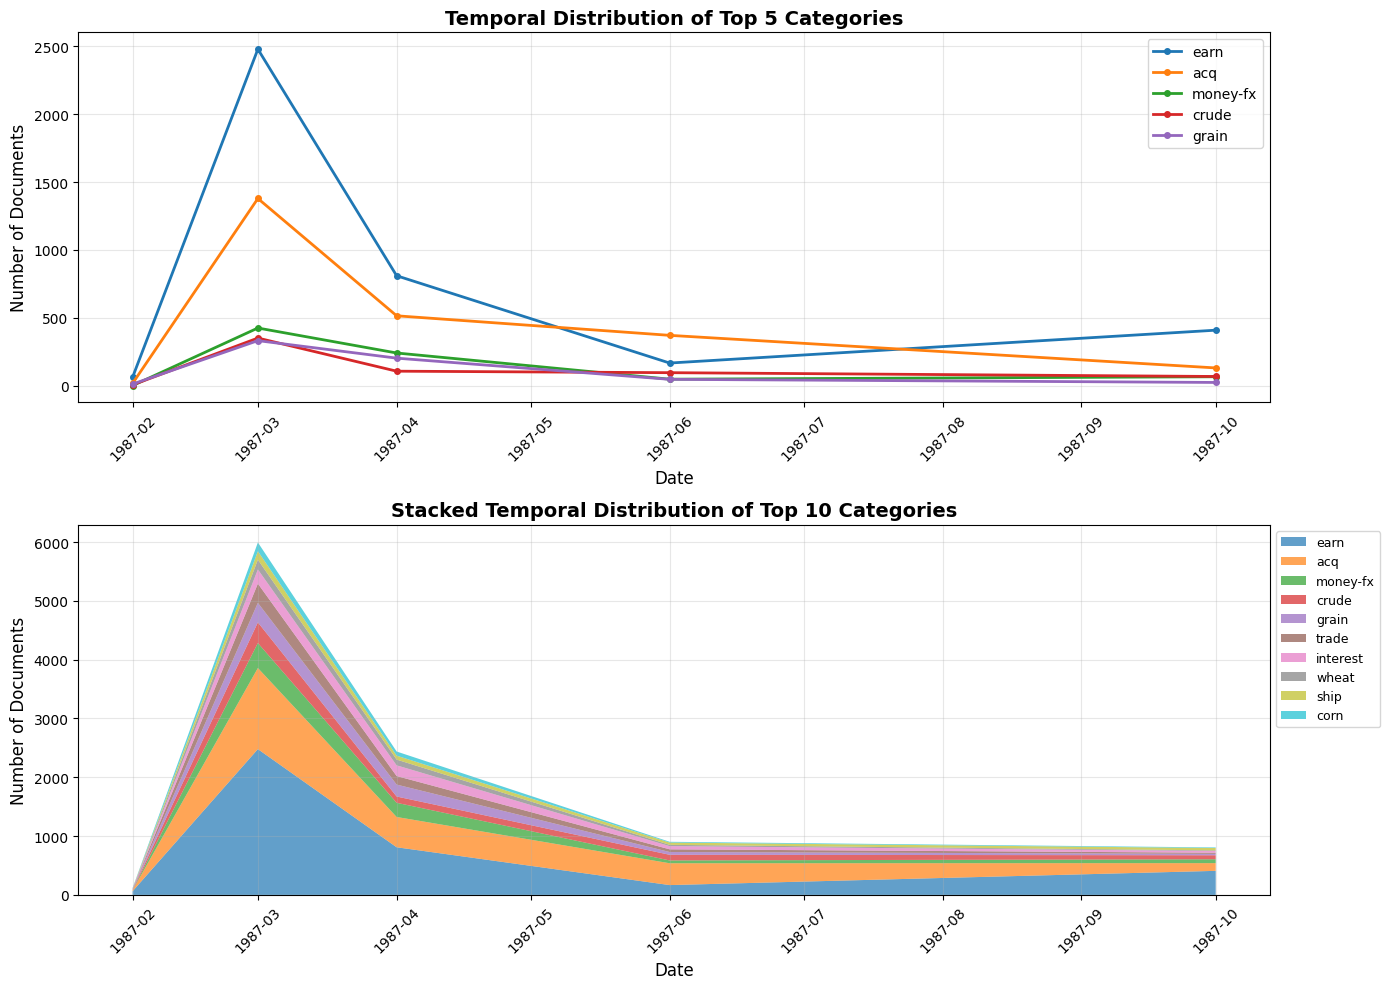

In [17]:
# Temporal distribution of top categories
# Get top 10 topics
top_topics = topic_counts.most_common(10)
top_topic_names = [t[0] for t in top_topics]

# Filter documents with dates and at least one topic
df_with_dates = df_reuters[df_reuters['date'].notna()].copy()
df_with_dates['date'] = pd.to_datetime(df_with_dates['date'], errors='coerce')

# Create month-year column for grouping
df_with_dates['month'] = df_with_dates['date'].dt.to_period('M')

# For each top topic, count documents per month
topic_temporal_data = {}
for topic_name in top_topic_names:
    # Create a boolean column for this topic
    df_with_dates[f'has_{topic_name}'] = df_with_dates['topics'].apply(lambda x: topic_name in x)
    # Group by month and count
    monthly_counts = df_with_dates[df_with_dates[f'has_{topic_name}']].groupby('month').size()
    topic_temporal_data[topic_name] = monthly_counts

# Plot temporal distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Line plot of top 5 topics over time
ax1 = axes[0]
for i, topic_name in enumerate(top_topic_names[:5]):
    if topic_name in topic_temporal_data and len(topic_temporal_data[topic_name]) > 0:
        data = topic_temporal_data[topic_name]
        ax1.plot(data.index.to_timestamp(), data.values, marker='o', label=topic_name, linewidth=2, markersize=4)

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Documents', fontsize=12)
ax1.set_title('Temporal Distribution of Top 5 Categories', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Stacked area chart for top 10 topics
ax2 = axes[1]
# Prepare data for stacked area
all_months = sorted(set().union(*[set(data.index) for data in topic_temporal_data.values()]))
stacked_data = []
for topic_name in top_topic_names:
    if topic_name in topic_temporal_data:
        data = topic_temporal_data[topic_name].reindex(all_months, fill_value=0)
        stacked_data.append(data.values)

if stacked_data and all_months:
    timestamps = [m.to_timestamp() for m in all_months]
    ax2.stackplot(timestamps, *stacked_data, labels=top_topic_names, alpha=0.7)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Number of Documents', fontsize=12)
    ax2.set_title('Stacked Temporal Distribution of Top 10 Categories', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Extract date from dateline using regex
import re
from datetime import datetime

def extract_date_from_dateline(dateline):
    """Extract date from Reuters dateline."""
    if not dateline or pd.isna(dateline):
        return None
    
    # Common date patterns in Reuters datelines
    # Examples: "LONDON, March 3", "WASHINGTON, Feb 26", etc.
    months = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12,
        'january': 1, 'february': 2, 'march': 3, 'april': 4, 'june': 6,
        'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12
    }
    
    # Pattern: Month Day or Month DD
    pattern = r'(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\s+(\d{1,2})'
    match = re.search(pattern, dateline.lower())
    
    if match:
        month_str = match.group(1)
        day = int(match.group(2))
        month = months.get(month_str)
        if month:
            # Reuters-21578 is from 1987, use that as default year
            return datetime(1987, month, min(day, 28))  # cap day at 28 to avoid invalid dates
    
    return None

# Apply date extraction
df_reuters['date'] = df_reuters['dateline'].apply(extract_date_from_dateline)
print(f"Successfully extracted dates for {df_reuters['date'].notna().sum()} out of {len(df_reuters)} documents")
print(f"\nDate range: {df_reuters['date'].min()} to {df_reuters['date'].max()}")

Successfully extracted dates for 18925 out of 21578 documents

Date range: 1987-01-28 00:00:00 to 1987-10-28 00:00:00


In [ ]:
# Count place/location frequencies
from collections import Counter

all_places = []
for places_list in df_reuters['places']:
    all_places.extend(places_list)

place_counts = Counter(all_places)
print(f"Total unique places: {len(place_counts)}")
print(f"\nTop 20 most common places:")
for place, count in place_counts.most_common(20):
    print(f"  {place}: {count}")

Total unique places: 147

Top 20 most common places:
  usa: 12542
  uk: 1489
  japan: 1138
  canada: 1104
  west-germany: 567
  france: 469
  brazil: 332
  australia: 270
  china: 223
  ussr: 216
  switzerland: 214
  belgium: 214
  netherlands: 196
  iran: 179
  italy: 170
  hong-kong: 142
  philippines: 136
  taiwan: 128
  spain: 115
  south-africa: 113


In [ ]:
# Summary statistics for locations
print("\nLocation diversity over time (number of unique places per month):")
place_diversity = df_with_dates.groupby('month')['places'].apply(
    lambda x: len(set([p for places in x for p in places]))
)
print(place_diversity)

print("\n" + "="*80)
print("\nTop locations by month (March 1987 - peak activity):")
march_data = df_with_dates[df_with_dates['month'] == '1987-03']
march_places = []
for places_list in march_data['places']:
    march_places.extend(places_list)
march_place_counts = Counter(march_places)
for place, count in march_place_counts.most_common(15):
    print(f"  {place}: {count}")


Location diversity over time (number of unique places per month):
month
1987-01      1
1987-02     28
1987-03    134
1987-04    115
1987-05      5
1987-06    110
1987-07      1
1987-10     71
Freq: M, Name: places, dtype: int64


Top locations by month (March 1987 - peak activity):
  usa: 6857
  uk: 872
  canada: 596
  japan: 533
  west-germany: 302
  france: 251
  brazil: 201
  australia: 154
  belgium: 136
  china: 128
  switzerland: 122
  ussr: 121
  netherlands: 101
  italy: 89
  iran: 84


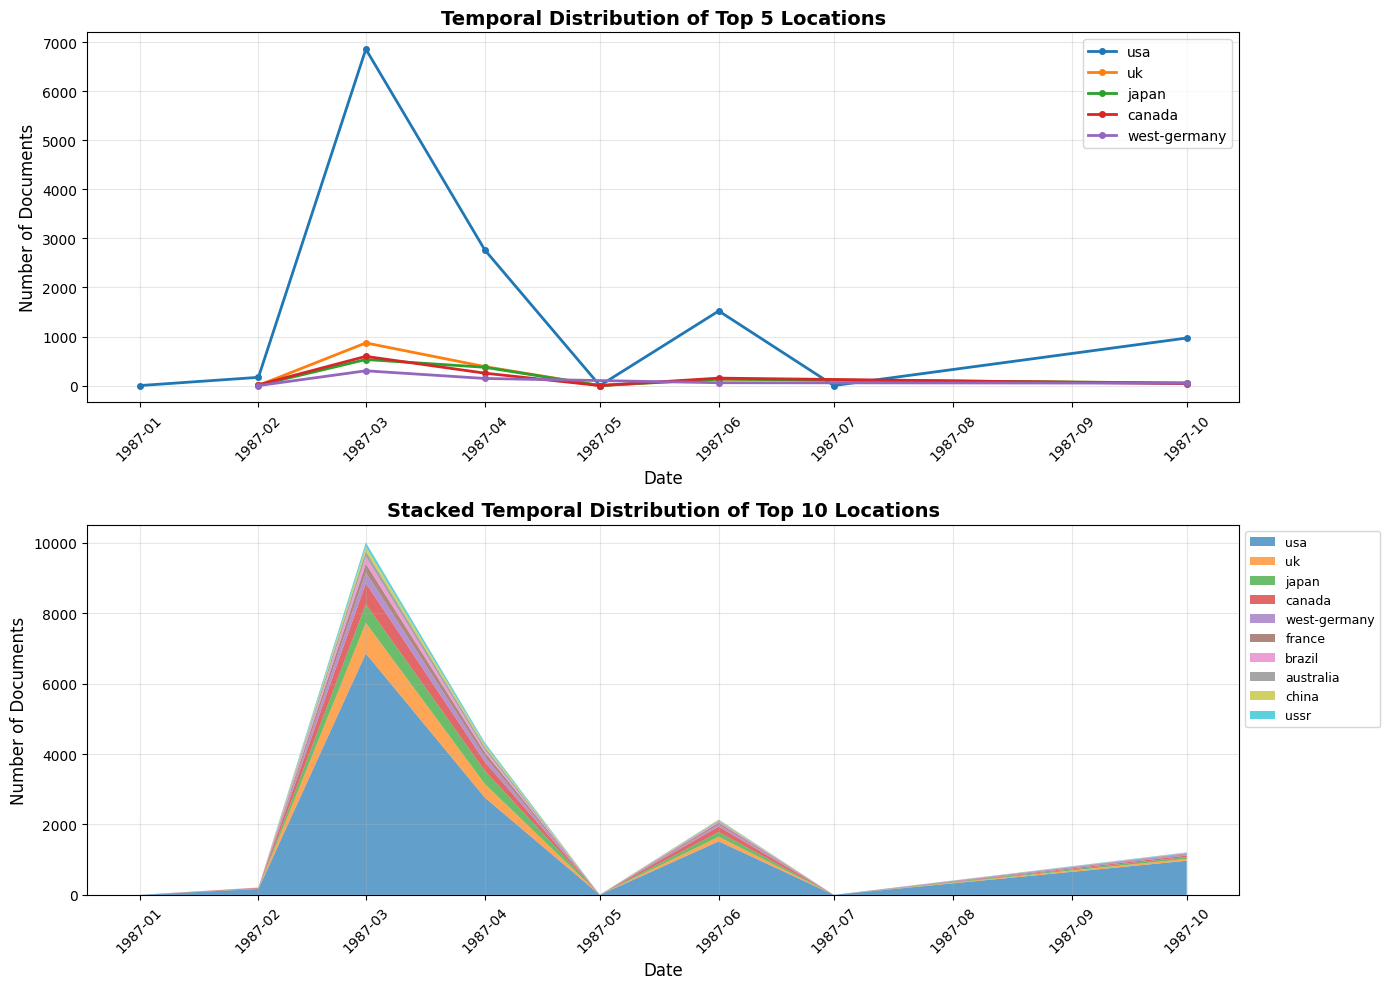

In [ ]:
# Temporal distribution of top locations
# Get top 10 places
top_places = place_counts.most_common(10)
top_place_names = [p[0] for p in top_places]

# For each top place, count documents per month
place_temporal_data = {}
for place_name in top_place_names:
    # Create a boolean column for this place
    df_with_dates[f'has_place_{place_name}'] = df_with_dates['places'].apply(lambda x: place_name in x)
    # Group by month and count
    monthly_counts = df_with_dates[df_with_dates[f'has_place_{place_name}']].groupby('month').size()
    place_temporal_data[place_name] = monthly_counts

# Plot temporal distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Line plot of top 5 places over time
ax1 = axes[0]
for i, place_name in enumerate(top_place_names[:5]):
    if place_name in place_temporal_data and len(place_temporal_data[place_name]) > 0:
        data = place_temporal_data[place_name]
        ax1.plot(data.index.to_timestamp(), data.values, marker='o', label=place_name, linewidth=2, markersize=4)

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Documents', fontsize=12)
ax1.set_title('Temporal Distribution of Top 5 Locations', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Stacked area chart for top 10 places
ax2 = axes[1]
# Prepare data for stacked area
all_months_places = sorted(set().union(*[set(data.index) for data in place_temporal_data.values()]))
stacked_data_places = []
for place_name in top_place_names:
    if place_name in place_temporal_data:
        data = place_temporal_data[place_name].reindex(all_months_places, fill_value=0)
        stacked_data_places.append(data.values)

if stacked_data_places and all_months_places:
    timestamps_places = [m.to_timestamp() for m in all_months_places]
    ax2.stackplot(timestamps_places, *stacked_data_places, labels=top_place_names, alpha=0.7)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Number of Documents', fontsize=12)
    ax2.set_title('Stacked Temporal Distribution of Top 10 Locations', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate category specialization by country
# Shows which countries have higher proportion of specific categories

print("Category Specialization by Country")
print("="*80)
print("\nShowing categories where each country has >20% of global coverage:\n")

for country in top_countries:
    country_specialties = []
    topic_dist = country_topic_distribution[country]
    
    for topic, country_count in topic_dist.most_common(20):
        # Get global count for this topic
        global_count = topic_counts[topic]
        if global_count > 0:
            percentage = (country_count / global_count) * 100
            if percentage > 20:  # Country has >20% of global coverage for this topic
                country_specialties.append((topic, country_count, percentage))
    
    if country_specialties:
        print(f"{country.upper()}:")
        for topic, count, pct in country_specialties:
            print(f"  {topic}: {count} docs ({pct:.1f}% of global {topic} coverage)")
        print()

Category Specialization by Country

Showing categories where each country has >20% of global coverage:

USA:
  earn: 3200 docs (80.3% of global earn coverage)
  acq: 1865 docs (76.2% of global acq coverage)
  grain: 365 docs (58.1% of global grain coverage)
  trade: 314 docs (56.9% of global trade coverage)
  crude: 298 docs (47.0% of global crude coverage)
  money-fx: 238 docs (29.7% of global money-fx coverage)
  wheat: 186 docs (60.8% of global wheat coverage)
  corn: 168 docs (66.1% of global corn coverage)
  interest: 167 docs (32.6% of global interest coverage)
  ship: 118 docs (38.7% of global ship coverage)
  nat-gas: 94 docs (72.3% of global nat-gas coverage)
  oilseed: 93 docs (48.4% of global oilseed coverage)
  livestock: 85 docs (74.6% of global livestock coverage)
  soybean: 82 docs (68.3% of global soybean coverage)
  dlr: 79 docs (36.4% of global dlr coverage)
  money-supply: 75 docs (39.5% of global money-supply coverage)
  carcass: 50 docs (66.7% of global carcass cov

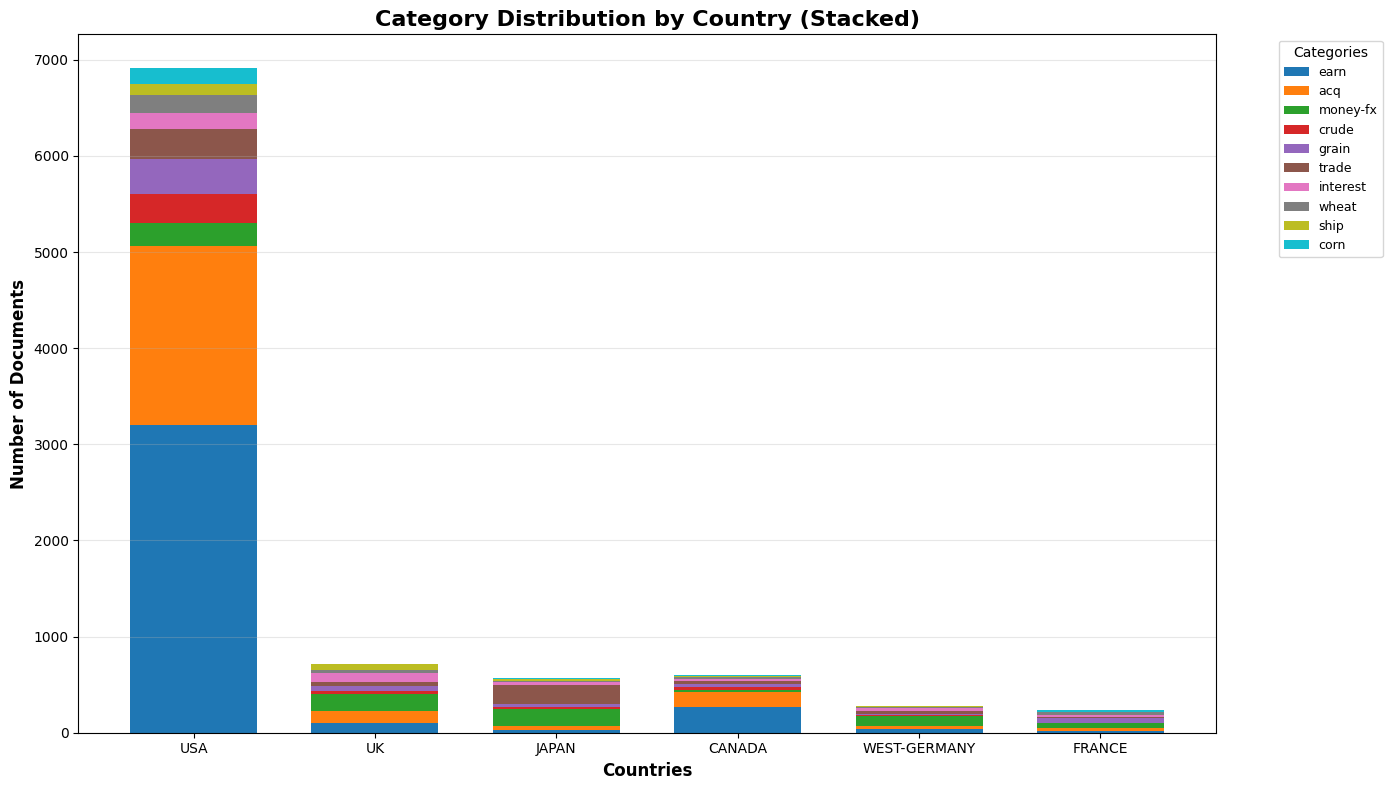

In [ ]:
# Stacked bar chart showing category distribution by country
fig, ax = plt.subplots(figsize=(14, 8))

# Get top 10 topics
top_10_topics = [t[0] for t in topic_counts.most_common(10)]

# Prepare data
x = np.arange(len(top_countries))
width = 0.7

# Stack the bars
bottom = np.zeros(len(top_countries))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, topic in enumerate(top_10_topics):
    values = [country_topic_distribution[country].get(topic, 0) for country in top_countries]
    ax.bar(x, values, width, label=topic, bottom=bottom, color=colors[idx])
    bottom += values

ax.set_xlabel('Countries', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Documents', fontsize=12, fontweight='bold')
ax.set_title('Category Distribution by Country (Stacked)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in top_countries])
ax.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

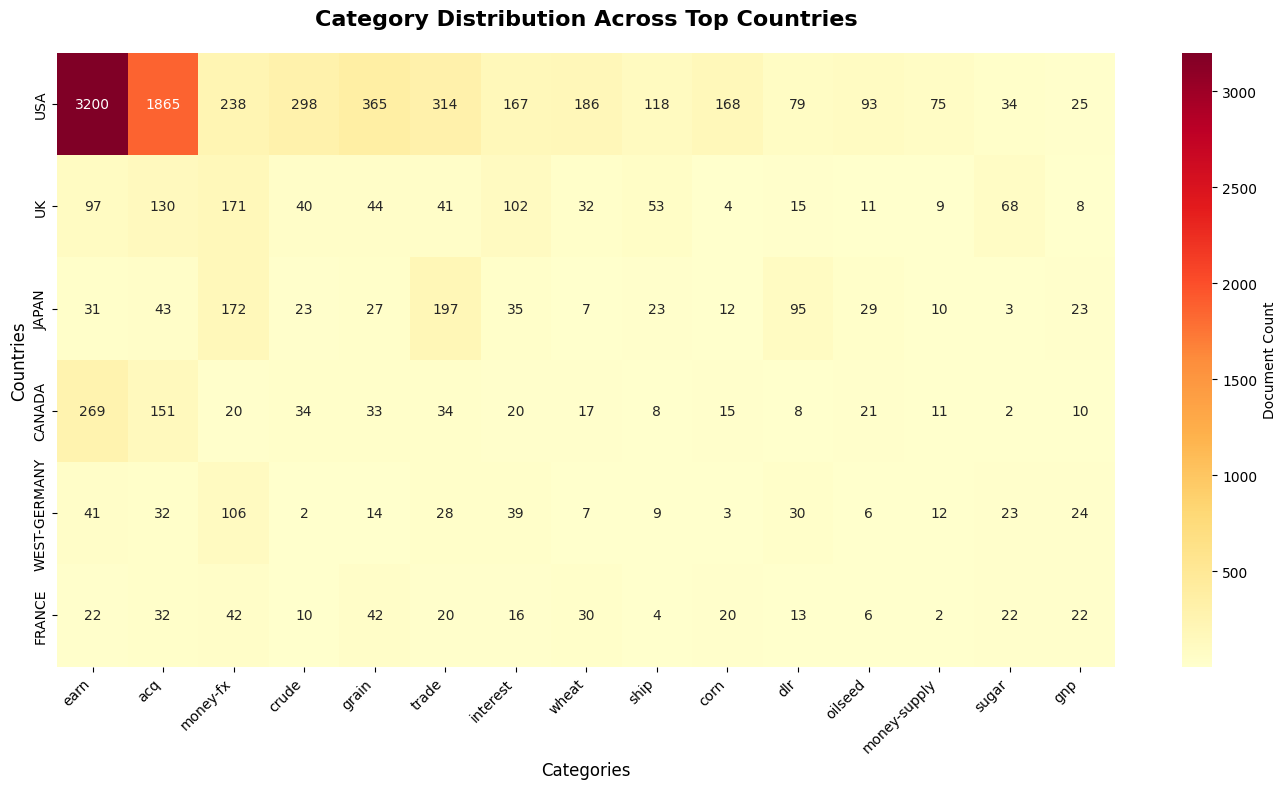

In [ ]:
# Create a heatmap showing category distribution across countries
import seaborn as sns

# Get top 15 topics overall
top_15_topics = [t[0] for t in topic_counts.most_common(15)]

# Create a matrix: rows = countries, columns = topics
heatmap_data = []
country_labels = []

for country in top_countries:
    country_labels.append(country.upper())
    row = []
    topic_dist = country_topic_distribution[country]
    for topic in top_15_topics:
        row.append(topic_dist.get(topic, 0))
    heatmap_data.append(row)

# Create DataFrame for heatmap
heatmap_df = pd.DataFrame(heatmap_data, index=country_labels, columns=top_15_topics)

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Document Count'})
plt.title('Category Distribution Across Top Countries', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Categories', fontsize=12)
plt.ylabel('Countries', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Analyze category distribution by country
# For top countries, show which categories are most common

top_countries = ['usa', 'uk', 'japan', 'canada', 'west-germany', 'france']

# Create a mapping of country -> topic counts
country_topic_distribution = {}

for country in top_countries:
    # Filter documents that mention this country
    country_docs = df_reuters[df_reuters['places'].apply(lambda x: country in x)]
    
    # Count topics in these documents
    country_topics = []
    for topics_list in country_docs['topics']:
        country_topics.extend(topics_list)
    
    topic_counts_country = Counter(country_topics)
    country_topic_distribution[country] = topic_counts_country
    
    print(f"\n{country.upper()} - Top 10 Categories:")
    print(f"Total documents: {len(country_docs)}")
    print(f"Documents with topics: {len([t for t in country_docs['topics'] if len(t) > 0])}")
    for topic, count in topic_counts_country.most_common(10):
        print(f"  {topic}: {count}")


USA - Top 10 Categories:
Total documents: 12541
Documents with topics: 6968
  earn: 3200
  acq: 1865
  grain: 365
  trade: 314
  crude: 298
  money-fx: 238
  wheat: 186
  corn: 168
  interest: 167
  ship: 118

UK - Top 10 Categories:
Total documents: 1485
Documents with topics: 820
  money-fx: 171
  acq: 130
  interest: 102
  earn: 97
  sugar: 68
  ship: 53
  grain: 44
  trade: 41
  crude: 40
  cocoa: 35

JAPAN - Top 10 Categories:
Total documents: 1136
Documents with topics: 630
  trade: 197
  money-fx: 172
  dlr: 95
  yen: 45
  acq: 43
  interest: 35
  earn: 31
  oilseed: 29
  grain: 27
  crude: 23

CANADA - Top 10 Categories:
Total documents: 1104
Documents with topics: 717
  earn: 269
  acq: 151
  gold: 48
  crude: 34
  trade: 34
  grain: 33
  oilseed: 21
  copper: 20
  money-fx: 20
  interest: 20

WEST-GERMANY - Top 10 Categories:
Total documents: 567
Documents with topics: 347
  money-fx: 106
  earn: 41
  interest: 39
  acq: 32
  dlr: 30
  trade: 28
  gnp: 24
  sugar: 23
  grain

In [ ]:
# Path to Reuters-21578 dataset
reuters_dir = "data/reuters/"

In [ ]:
# Klassenverteilung fuer subsamplete Reuters-Trainingsdaten (1%-10%)
import pandas as pd

classes = ['earn', 'acq', 'money-fx', 'grain', 'crude', 'trade', 'interest', 'ship', 'wheat', 'corn']

# 1) Falls bereits ein vorbereitetes df_train existiert (mit Labelspalten), nutze es
if 'df_train' in globals() and set(classes).issubset(set(df_train.columns)):
    train_full = df_train.copy()

# 2) Sonst aus dem geladenen Reuters-DataFrame ableiten
else:
    train_full = df_reuters[df_reuters['lewissplit'].astype(str).str.upper() == 'TRAIN'].copy()
    train_full = train_full[train_full['topics'].apply(lambda x: isinstance(x, list))].copy()

    # Nur Dokumente behalten, die mindestens eine der 10 Klassen enthalten
    train_full = train_full[
        train_full['topics'].apply(lambda ts: any(c in ts for c in classes))
    ].copy()

    # Multi-Label-Spalten (0/1) erstellen
    for c in classes:
        train_full[c] = train_full['topics'].apply(lambda ts: int(c in ts))

# Shuffle wie in eval_reuters_data_availability.py
train_full = train_full.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Basis-Trainingsdaten: {len(train_full)} Samples")
print("Klassenanteile im Voll-Trainingssatz:")
full_counts = train_full[classes].sum().sort_values(ascending=False)
full_pct = (full_counts / len(train_full) * 100).round(2)
print(pd.DataFrame({'count': full_counts, 'pct_docs': full_pct}))

print("\n" + "="*90)
print("Klassenverteilung nach Subsampling (n = max(100, int(len(train)*pct)), random_state=42)")

rows = []
for pct in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]:
    n_train = max(100, int(len(train_full) * pct))
    sampled_train = train_full.sample(n=n_train, random_state=42).reset_index(drop=True)

    counts = sampled_train[classes].sum()
    for cls in classes:
        rows.append({
            'train_pct': f"{int(pct*100)}%",
            'n_train': n_train,
            'class': cls,
            'count': int(counts[cls]),
            'pct_docs': round(float(counts[cls]) / n_train * 100, 2)
        })

dist_df = pd.DataFrame(rows)

# Kompakter Pivot-Output: Prozentanteile je Klasse pro Sampling-Stufe
pivot_pct = dist_df.pivot(index='class', columns='train_pct', values='pct_docs')[
    ['1%', '2%', '3%', '4%', '5%', '6%', '7%', '8%', '9%', '10%']
]

print("\nProzentanteile pro Klasse (% der Dokumente im jeweiligen Subsample):")
print(pivot_pct)

print("\nAbsolute Counts fuer 10%-Subsample:")
print(
    dist_df[dist_df['train_pct'] == '10%'][['class', 'count', 'pct_docs']]
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

Basis-Trainingsdaten: 6494 Samples
Klassenanteile im Voll-Trainingssatz:
          count  pct_docs
earn       2877     44.30
acq        1650     25.41
money-fx    539      8.30
grain       434      6.68
crude       391      6.02
trade       369      5.68
interest    347      5.34
wheat       212      3.26
ship        198      3.05
corn        182      2.80

Klassenverteilung nach Subsampling (n = max(100, int(len(train)*pct)), random_state=42)

Prozentanteile pro Klasse (% der Dokumente im jeweiligen Subsample):
train_pct    1%     2%     3%     4%     5%     6%     7%     8%     9%    10%
class                                                                         
acq        27.0  26.36  24.74  23.55  24.38  23.91  23.13  22.93  22.43  23.42
corn        1.0   1.55   2.06   2.32   1.85   1.54   1.76   1.93   2.05   2.00
crude       9.0   9.30   8.25   8.88   8.33   7.71   7.49   7.32   6.68   7.09
earn       45.0  44.19  42.27  42.08  43.52  44.22  44.49  43.93  45.21  45.30
grain   

In [ ]:
# Validation vs sampled-training class distribution (same 10-label setup)
import pandas as pd

# Validation labels are taken from experiment prediction files (true labels are stored in columns)
val_pred_path = (
    "outputs/data_availability_experiments_reuters/1%/"
    "reuters_train1_20251209_163237/experiments/"
    "2025-12-09_16-32-57_reuters_train1_20251209_163237/"
    "predictions/validation_predictions_aa685a6f1bc6.csv"
)

val_df = pd.read_csv(val_pred_path)
val_counts = val_df[classes].sum().sort_values(ascending=False)
val_pct = (val_counts / len(val_df) * 100).round(2)

print(f"Validation samples: {len(val_df)}")
print("Validation distribution (% docs containing class):")
print(pd.DataFrame({"count": val_counts.astype(int), "pct_docs": val_pct}))

# Training distributions for sampled train sets (already created in dist_df)
train_pct_order = ['1%', '2%', '3%', '4%', '5%', '6%', '7%', '8%', '9%', '10%']

train_dist = (
    dist_df
    .pivot(index='class', columns='train_pct', values='pct_docs')
    .reindex(columns=train_pct_order)
)

print("\n" + "="*90)
print("Sampled TRAIN distribution (% docs containing class):")
print(train_dist)

# Also show sample counts per sampled train split
train_sizes = (
    dist_df[['train_pct', 'n_train']]
    .drop_duplicates()
    .set_index('train_pct')
    .reindex(train_pct_order)
)
print("\nTrain sample sizes:")
print(train_sizes.T)

Validation samples: 647
Validation distribution (% docs containing class):
          count  pct_docs
earn        288     44.51
acq         165     25.50
money-fx     54      8.35
grain        43      6.65
crude        39      6.03
trade        37      5.72
interest     35      5.41
wheat        21      3.25
ship         20      3.09
corn         18      2.78

Sampled TRAIN distribution (% docs containing class):
train_pct    1%     2%     3%     4%     5%     6%     7%     8%     9%    10%
class                                                                         
acq        27.0  26.36  24.74  23.55  24.38  23.91  23.13  22.93  22.43  23.42
corn        1.0   1.55   2.06   2.32   1.85   1.54   1.76   1.93   2.05   2.00
crude       9.0   9.30   8.25   8.88   8.33   7.71   7.49   7.32   6.68   7.09
earn       45.0  44.19  42.27  42.08  43.52  44.22  44.49  43.93  45.21  45.30
grain       4.0   3.88   5.15   6.56   6.48   5.91   6.61   7.13   7.19   7.09
interest    6.0   6.20   6.70  

## 4. Nasdaq

In [4]:
"""
Fetch daily commodity futures data for 1987 via Nasdaq Data Link (formerly Quandl).
Continuous futures series go back to the 1980s, unlike yfinance which only
stores the current front-month contract.

Requirements:
    pip install nasdaq-data-link pandas

API key:
    Free registration at https://data.nasdaq.com/sign-up
    Then set: export NASDAQ_DATA_LINK_API_KEY=your_key_here
    Or paste it directly into API_KEY below.
"""

import os
import pandas as pd
import nasdaqdatalink

# ── Config ────────────────────────────────────────────────────────────────────
API_KEY = os.environ.get("NASDAQ_DATA_LINK_API_KEY", "YOUR_API_KEY_HERE")
START   = "1987-01-01"
END     = "1987-12-31"
OUT     = "data/Reuters commodities/reuters_quandl_daily_1987.csv"

nasdaqdatalink.ApiConfig.api_key = API_KEY

# ── Series mapping ─────────────────────────────────────────────────────────────
# Quandl dataset: CHRIS = Wiki Continuous Futures (free, stitched back-adjusted)
# Format: CHRIS/{EXCHANGE}_{TICKER}{N}  where N=1 is front month
#
# Reuters label -> (quandl_code, description)
COMMODITIES = {
    # Precious metals
    "gold":      ("CHRIS/CME_GC1",  "Gold Futures continuous front month (COMEX)"),
    "silver":    ("CHRIS/CME_SI1",  "Silver Futures continuous front month (COMEX)"),
    "platinum":  ("CHRIS/CME_PL1",  "Platinum Futures continuous front month (NYMEX)"),
    "palladium": ("CHRIS/CME_PA1",  "Palladium Futures continuous front month (NYMEX)"),

    # Base metals
    "copper":    ("CHRIS/CME_HG1",  "Copper Futures continuous front month (COMEX)"),

    # Energy
    "gas":       ("CHRIS/CME_RB1",  "RBOB Gasoline Futures continuous (NYMEX)"),

    # Grains & oilseeds
    "wheat":     ("CHRIS/CME_W1",   "Wheat Futures continuous front month (CBOT)"),
    "corn":      ("CHRIS/CME_C1",   "Corn Futures continuous front month (CBOT)"),
    "oat":       ("CHRIS/CME_O1",   "Oat Futures continuous front month (CBOT)"),
    "soybean":   ("CHRIS/CME_S1",   "Soybean Futures continuous front month (CBOT)"),
    "soy-meal":  ("CHRIS/CME_SM1",  "Soybean Meal Futures continuous (CBOT)"),
    "soy-oil":   ("CHRIS/CME_BO1",  "Soybean Oil Futures continuous (CBOT)"),
    "grain":     ("CHRIS/CME_W1",   "Wheat as grain proxy (CBOT)"),
    "meal-feed": ("CHRIS/CME_SM1",  "Soybean meal as meal-feed proxy (CBOT)"),
    "oilseed":   ("CHRIS/CME_S1",   "Soybean as oilseed proxy (CBOT)"),
    "veg-oil":   ("CHRIS/CME_BO1",  "Soy oil as veg-oil proxy (CBOT)"),

    # Softs
    "cocoa":     ("CHRIS/ICE_CC1",  "Cocoa Futures continuous front month (ICE)"),
    "coffee":    ("CHRIS/ICE_KC1",  "Coffee C Futures continuous front month (ICE)"),
    "sugar":     ("CHRIS/ICE_SB1",  "Sugar No.11 Futures continuous (ICE)"),
    "cotton":    ("CHRIS/ICE_CT1",  "Cotton No.2 Futures continuous (ICE)"),
    "orange":    ("CHRIS/ICE_OJ1",  "Orange Juice Futures continuous (ICE)"),

    # Livestock
    "hog":       ("CHRIS/CME_LN1",  "Lean Hog Futures continuous (CME)"),
    "l-cattle":  ("CHRIS/CME_LC1",  "Live Cattle Futures continuous (CME)"),
    "livestock": ("CHRIS/CME_LC1",  "Live Cattle as livestock proxy (CME)"),
    "f-cattle":  ("CHRIS/CME_FC1",  "Feeder Cattle Futures continuous (CME)"),

    # Lumber
    "lumber":    ("CHRIS/CME_LB1",  "Lumber Futures continuous (CME)"),
}

# ── Fetch ─────────────────────────────────────────────────────────────────────
def fetch_all():
    # Deduplicate by quandl code
    code_to_labels = {}
    for label, (code, desc) in COMMODITIES.items():
        code_to_labels.setdefault(code, []).append((label, desc))

    all_rows = []
    print(f"Fetching {len(code_to_labels)} unique series for {START} to {END}...\n")

    for code, label_descs in code_to_labels.items():
        labels = [ld[0] for ld in label_descs]
        desc   = label_descs[0][1]
        try:
            df = nasdaqdatalink.get(
                code,
                start_date=START,
                end_date=END,
                returns="pandas",
            )

            if df.empty:
                print(f"  ✗ {code:25s} ({', '.join(labels)}) -> no data")
                continue

            # CHRIS datasets have columns: Open, High, Low, Last, Change,
            # Settle, Volume, Previous Day Open Interest
            # Use Settle if available, else Last, else Close
            price_col = None
            for col in ["Settle", "Last", "Close"]:
                if col in df.columns:
                    price_col = col
                    break

            if price_col is None:
                print(f"  ✗ {code:25s} ({', '.join(labels)}) -> no price column found")
                continue

            prices = df[price_col].dropna()
            n = len(prices)
            print(f"  ✓ {code:25s} ({', '.join(labels)}) -> {n} observations [{price_col}]")

            for date, price in prices.items():
                date_str = date.strftime("%Y-%m-%d") if hasattr(date, "strftime") else str(date)
                for label in labels:
                    all_rows.append({
                        "label":       label,
                        "quandl_code": code,
                        "description": COMMODITIES[label][1],
                        "date":        date_str,
                        "close":       round(float(price), 4),
                    })

        except Exception as e:
            print(f"  ✗ {code:25s} ({', '.join(labels)}) -> error: {e}")

    if not all_rows:
        print("\nNo data retrieved. Check your API key and internet connection.")
        return

    result = pd.DataFrame(
        all_rows,
        columns=["label", "quandl_code", "description", "date", "close"]
    )
    result = result.sort_values(["label", "date"]).reset_index(drop=True)

    os.makedirs(os.path.dirname(OUT), exist_ok=True)
    result.to_csv(OUT, index=False)

    print(f"\nSaved {len(result)} rows across {result['label'].nunique()} labels")
    print(f"Output: {OUT}")

    # Summary table
    print("\n--- Observations per label ---")
    summary = (
        result.groupby(["label", "quandl_code"])["date"]
        .count()
        .rename("observations")
        .reset_index()
        .sort_values("label")
    )
    print(summary.to_string(index=False))

if __name__ == "__main__":
    fetch_all()

Fetching 21 unique series for 1987-01-01 to 1987-12-31...

  ✗ CHRIS/CME_GC1             (gold) -> error: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@data.nasdaq.com.
  ✗ CHRIS/CME_SI1             (silver) -> error: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@data.nasdaq.com.
  ✗ CHRIS/CME_PL1             (platinum) -> error: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@data.nasdaq.com.
  ✗ CHRIS/CME_PA1             (palladium) -> error: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@data.nasdaq.com.
  ✗ CHRIS/CME_HG1             (copper) -> error: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@data.nasdaq.com.
  ✗ CHRIS/CME_RB1           